# Генерация синтетических данных с использованием Faker

In [1]:
!pip install faker


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Задание на самостоятельную работу
Создать синтетический набор данных, сохранить его в csv файлы, построить на основе данных онтологию, вывести онтограф.


### Вариант 3. Медицинские пациенты и приёмы
Сущности:
- Пациент: id, ФИО, дата рождения, пол, полис ОМС, СНИЛС, адрес, телефон.
- Врач: id, ФИО, специальность, кабинет.
- Приём: id, дата и время, id пациента, id врача, диагноз (код МКБ-10), жалобы, назначения (JSON-массив объектов: {лекарство, дозировка, курс}).
- Больничный лист: id, id приёма, дата начала, дата окончания, диагноз.

Объём: 2000 пациентов, 50 врачей, 5–10 приёмов на пациента за последние 2 года, часть с больничными.

Онтология:
- Классы: Пациент, Врач, Приём, БольничныйЛист.
- Связи: пациент посещает врача (приём), по приёму может быть открыт больничный, назначения хранятся в JSON приёма (Атрибут класса Прием).


In [2]:
!pip install faker pandas owlready2 graphviz pydotplus


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Импортируем необходимые библиотеки
import pandas as pd
import random
import json
from faker import Faker
from datetime import datetime, timedelta

# Инициализация генератора (русская локаль)
fake = Faker('ru_RU')
Faker.seed(42)
random.seed(42)

# 1. Генерация пациентов
def generate_patients(n: int) -> pd.DataFrame:
    patients = []
    for i in range(1, n + 1):
        last_name = fake.last_name()
        first_name = fake.first_name()
        patronymic = fake.middle_name()
        birth_date = fake.date_of_birth(minimum_age=18, maximum_age=90)
        gender = random.choice(['М', 'Ж'])
        insurance_policy = fake.bothify(text='##############')
        snils = fake.bothify(text='###-###-### ##')
        address = fake.address().replace('\n', ', ')
        phone = fake.phone_number()
        patients.append({
            'patient_id': i,
            'last_name': last_name,
            'first_name': first_name,
            'patronymic': patronymic,
            'birth_date': birth_date,
            'gender': gender,
            'insurance_policy': insurance_policy,
            'snils': snils,
            'address': address,
            'phone': phone
        })
    return pd.DataFrame(patients)

# 2. Генерация врачей
def generate_doctors(n: int) -> pd.DataFrame:
    specialties = ['Терапевт', 'Хирург', 'Офтальмолог', 'ЛОР', 'Невролог', 
                   'Кардиолог', 'Дерматолог', 'Педиатр', 'Психиатр', 'Эндокринолог']
    doctors = []
    for i in range(1, n + 1):
        last_name = fake.last_name()
        first_name = fake.first_name()
        patronymic = fake.middle_name()
        specialty = random.choice(specialties)
        office = random.randint(100, 500)
        doctors.append({
            'doctor_id': i,
            'last_name': last_name,
            'first_name': first_name,
            'patronymic': patronymic,
            'specialty': specialty,
            'office': office
        })
    return pd.DataFrame(doctors)

# 3. Генерация приёмов (исправленная версия – лекарства из списка)
def generate_appointments(patients_df: pd.DataFrame, doctors_df: pd.DataFrame, 
                          min_per_patient=5, max_per_patient=10) -> pd.DataFrame:
    appointments = []
    app_id = 1
    start_date = datetime.now() - timedelta(days=2*365)
    end_date = datetime.now()
    
    # Словарь диагнозов
    diagnoses = {
        'J06.9': 'Острая респираторная инфекция верхних дыхательных путей',
        'I10': 'Эссенциальная гипертензия',
        'E11': 'Сахарный диабет 2 типа',
        'M54.5': 'Боль в пояснице',
        'H25': 'Старческая катаракта',
        'J45': 'Астма',
        'K29.7': 'Гастрит',
        'N20': 'Мочекаменная болезнь'
    }
    
    complaints_list = [
        'Кашель, насморк, температура',
        'Головная боль, головокружение',
        'Боли в пояснице, ограничение движений',
        'Одышка, слабость',
        'Боль в горле, осиплость голоса',
        'Снижение зрения',
        'Боли в животе, тошнота',
        'Частое мочеиспускание'
    ]
    
    # *** СПИСОК ЛЕКАРСТВ (как аналог списка специальностей) ***
    medications = [
        'Амоксициллин', 'Парацетамол', 'Ибупрофен', 'Но-шпа', 'Лозартан',
        'Метформин', 'Аторвастатин', 'Омепразол', 'Диклофенак', 'Цетрин',
        'Амлодипин', 'Преднизолон', 'Дексаметазон', 'Флуоксетин', 'Азитромицин'
    ]
    
    for _, patient in patients_df.iterrows():
        patient_id = patient['patient_id']
        num_appointments = random.randint(min_per_patient, max_per_patient)
        dates = sorted([fake.date_between(start_date=start_date, end_date=end_date) 
                        for _ in range(num_appointments)])
        
        for visit_date in dates:
            doctor = doctors_df.sample(1).iloc[0]
            diagnosis_code = random.choice(list(diagnoses.keys()))
            complaints = random.choice(complaints_list)
            
            # *** Генерация назначений – лекарства берутся из списка medications ***
            prescriptions = []
            num_drugs = random.randint(0, 3)
            for _ in range(num_drugs):
                # Выбираем случайное лекарство из списка
                drug = random.choice(medications) + " " + str(random.randint(100, 500)) + "мг"
                dosage = f"{random.randint(1,3)} раз(а) в день по {random.randint(1,2)} таб."
                duration = f"{random.randint(5,14)} дней"
                prescriptions.append({
                    'medication': drug,
                    'dosage': dosage,
                    'course': duration
                })
            
            appointments.append({
                'appointment_id': app_id,
                'datetime': datetime.combine(visit_date, fake.time_object()),
                'patient_id': patient_id,
                'doctor_id': doctor['doctor_id'],
                'diagnosis_code': diagnosis_code,
                'diagnosis_name': diagnoses[diagnosis_code],
                'complaints': complaints,
                'prescriptions': json.dumps(prescriptions, ensure_ascii=False)
            })
            app_id += 1
    return pd.DataFrame(appointments)

# 4. Генерация больничных листов
def generate_sick_leaves(appointments_df: pd.DataFrame) -> pd.DataFrame:
    sick_leaves = []
    sl_id = 1
    for _, app in appointments_df.iterrows():
        if random.random() < 0.3:
            start_date = app['datetime'].date()
            duration = random.randint(3, 15)
            end_date = start_date + timedelta(days=duration)
            sick_leaves.append({
                'sick_leave_id': sl_id,
                'appointment_id': app['appointment_id'],
                'start_date': start_date,
                'end_date': end_date,
                'diagnosis': app['diagnosis_name']
            })
            sl_id += 1
    return pd.DataFrame(sick_leaves)

# Генерация и сохранение CSV
patients_df = generate_patients(2000)
doctors_df = generate_doctors(50)
appointments_df = generate_appointments(patients_df, doctors_df, min_per_patient=5, max_per_patient=10)
sick_leaves_df = generate_sick_leaves(appointments_df)

patients_df.to_csv('patients.csv', index=False)
doctors_df.to_csv('doctors.csv', index=False)
appointments_df.to_csv('appointments.csv', index=False)
sick_leaves_df.to_csv('sick_leaves.csv', index=False)

print("Данные сгенерированы и сохранены.")

Данные сгенерированы и сохранены.


In [4]:
# Импортируем все классы и функции из библиотеки owlready2 для работы с онтологиями
from owlready2 import *
# Импортируем pandas для чтения CSV-файлов 
import pandas as pd

# Читаем CSV-файлы в pandas DataFrame (данные о пациентах, врачах, приёмах и больничных)
patients = pd.read_csv('patients.csv')
doctors = pd.read_csv('doctors.csv')
appointments = pd.read_csv('appointments.csv')
sick_leaves = pd.read_csv('sick_leaves.csv')

# Создаём пустую онтологию с указанным идентификатором
# Параметр – уникальный идентификатор онтологии 
onto = get_ontology("http://example.org/medical_ontology.owl")

# Открываем контекст онтологии для внесения изменений (добавления классов, свойств, индивидов)
with onto:

    # 1. Определяем классы (типы сущностей) 
    # Все классы наследуются от встроенного класса Thing (корень иерархии OWL)
    
    class Пациент(Thing):
        pass          # Класс, описывающий пациента (сущность с атрибутами и связями)
    
    class Врач(Thing):
        pass          # Класс, описывающий врача
    
    class Приём(Thing):
        pass          # Класс, описывающий приём (визит к врачу)
    
    class БольничныйЛист(Thing):
        pass          # Класс, описывающий больничный лист
    
    # 2. Определяем свойства (атрибуты и связи) 
    
    # DataProperty (связывают индивида с конкретным значением: строка, число) 
    # Свойство "имеет_ФИО" – применимо к пациентам и врачам, значение – строка
    class имеет_ФИО(DataProperty):
        domain = [Пациент, Врач]   # Область определения: к каким классам можно применить
        range = [str]              # Область значений: тип данных (строка)
    
    # Дата рождения – только для пациентов, значение – строка (дата)
    class дата_рождения(DataProperty):
        domain = [Пациент]
        range = [str]
    
    # Пол – только для пациентов, строка
    class пол(DataProperty):
        domain = [Пациент]
        range = [str]
    
    # Полис ОМС – строка (14 цифр)
    class полис_ОМС(DataProperty):
        domain = [Пациент]
        range = [str]
    
    # СНИЛС – строка в формате "###-###-### ##"
    class СНИЛС(DataProperty):
        domain = [Пациент]
        range = [str]
    
    # Адрес – строка
    class адрес(DataProperty):
        domain = [Пациент]
        range = [str]
    
    # Телефон – применим к пациентам и врачам
    class телефон(DataProperty):
        domain = [Пациент, Врач]
        range = [str]
    
    # Специальность врача – строка (например, "Терапевт")
    class специальность(DataProperty):
        domain = [Врач]
        range = [str]
    
    # Номер кабинета – целое число
    class кабинет(DataProperty):
        domain = [Врач]
        range = [int]
    
    # Дата и время приёма – строка (в формате "YYYY-MM-DD HH:MM:SS")
    class дата_время(DataProperty):
        domain = [Приём]
        range = [str]
    
    # Код диагноза по МКБ-10 – может быть у приёма и у больничного
    class диагноз_код(DataProperty):
        domain = [Приём, БольничныйЛист]
        range = [str]
    
    # Жалобы пациента – текстовая строка
    class жалобы(DataProperty):
        domain = [Приём]
        range = [str]
    
    # Назначения – JSON-строка (список лекарств с дозировками)
    class назначения(DataProperty):
        domain = [Приём]
        range = [str]
    
    # Дата начала больничного – строка
    class дата_начала(DataProperty):
        domain = [БольничныйЛист]
        range = [str]
    
    # Дата окончания больничного – строка
    class дата_окончания(DataProperty):
        domain = [БольничныйЛист]
        range = [str]
    
    # ObjectProperty (связывают индивида с другим индивидом) 
    # Связь "посещает_врача" – пациент может посещать врача (многие ко многим)
    class посещает_врача(ObjectProperty):
        domain = [Пациент]   # От кого идёт связь (субъект)
        range = [Врач]       # На кого указывает (объект)
    
    # Связь "проведён_приём" – пациент и врач связаны с конкретным приёмом
    class проведён_приём(ObjectProperty):
        domain = [Пациент, Врач]   # Может быть задан от пациента или врача
        range = [Приём]
    
    # Связь "открыт_больничный" – приём может иметь связанный больничный лист
    class открыт_больничный(ObjectProperty):
        domain = [Приём]
        range = [БольничныйЛист]
    
    # 3. Создаём индивидов (экземпляров классов) на основе данных из CSV 
    
    # Словари для быстрого доступа к созданным индивидам по их ID из CSV
    patient_instances = {}
    doctor_instances = {}
    appointment_instances = {}
    sick_leave_instances = {}
    
    # Создание индивидов-пациентов 
    # Перебираем каждую строку DataFrame patients
    for _, row in patients.iterrows():
        # Создаём индивида класса Пациент с уникальным именем "пациент_<id>"
        p = Пациент(f"пациент_{row['patient_id']}")
        # Формируем полное ФИО из трёх частей
        full_name = f"{row['last_name']} {row['first_name']} {row['patronymic']}"
        # Заполняем DataProperty значениями (owlready2 ожидает список, даже для одного значения)
        p.имеет_ФИО = [full_name]
        p.дата_рождения = [str(row['birth_date'])]
        p.пол = [row['gender']]
        p.полис_ОМС = [row['insurance_policy']]
        p.СНИЛС = [row['snils']]
        p.адрес = [row['address']]
        p.телефон = [row['phone']]
        # Сохраняем индивида в словарь для быстрого доступа по patient_id
        patient_instances[row['patient_id']] = p
    
    # Создание индивидов-врачей 
    for _, row in doctors.iterrows():
        d = Врач(f"врач_{row['doctor_id']}")
        full_name = f"{row['last_name']} {row['first_name']} {row['patronymic']}"
        d.имеет_ФИО = [full_name]
        d.специальность = [row['specialty']]
        d.кабинет = [row['office']]
        doctor_instances[row['doctor_id']] = d
    
    # Создание индивидов-приёмов
    for _, row in appointments.iterrows():
        a = Приём(f"приём_{row['appointment_id']}")
        a.дата_время = [row['datetime']]
        a.диагноз_код = [row['diagnosis_code']]
        a.жалобы = [row['complaints']]
        a.назначения = [row['prescriptions']]
        
        # Находим соответствующих пациентов и врачей по ID
        pat = patient_instances[row['patient_id']]
        doc = doctor_instances[row['doctor_id']]
        
        # Устанавливаем объектную связь "посещает_врача" (пациент -> врач)
        # .append используется, т.к. свойство может иметь несколько значений
        pat.посещает_врача.append(doc)
        
        # Сохраняем индивид приёма в словарь
        appointment_instances[row['appointment_id']] = a
    
    # Создание индивидов-больничных листов 
    for _, row in sick_leaves.iterrows():
        sl = БольничныйЛист(f"больничный_{row['sick_leave_id']}")
        sl.дата_начала = [str(row['start_date'])]
        sl.дата_окончания = [str(row['end_date'])]
        sl.диагноз_код = [row['diagnosis']]
        
        # Находим приём, к которому относится больничный
        app = appointment_instances[row['appointment_id']]
        # Устанавливаем связь "открыт_больничный" (приём -> больничный лист)
        app.открыт_больничный.append(sl)
        
        sick_leave_instances[row['sick_leave_id']] = sl


onto.save(file="medical_ontology.owl")
print("Онтология сохранена в medical_ontology.owl")

Онтология сохранена в medical_ontology.owl


In [5]:
!pip install networkx matplotlib pandas


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Узлы: ['Пациент', 'Врач', 'Приём', 'БольничныйЛист', 'посещает_врача', 'проведён_приём', 'открыт_больничный']
Рёбра: [('Пациент', 'посещает_врача'), ('Пациент', 'проведён_приём'), ('Врач', 'проведён_приём'), ('Приём', 'открыт_больничный'), ('посещает_врача', 'Врач'), ('проведён_приём', 'Приём'), ('открыт_больничный', 'БольничныйЛист')]


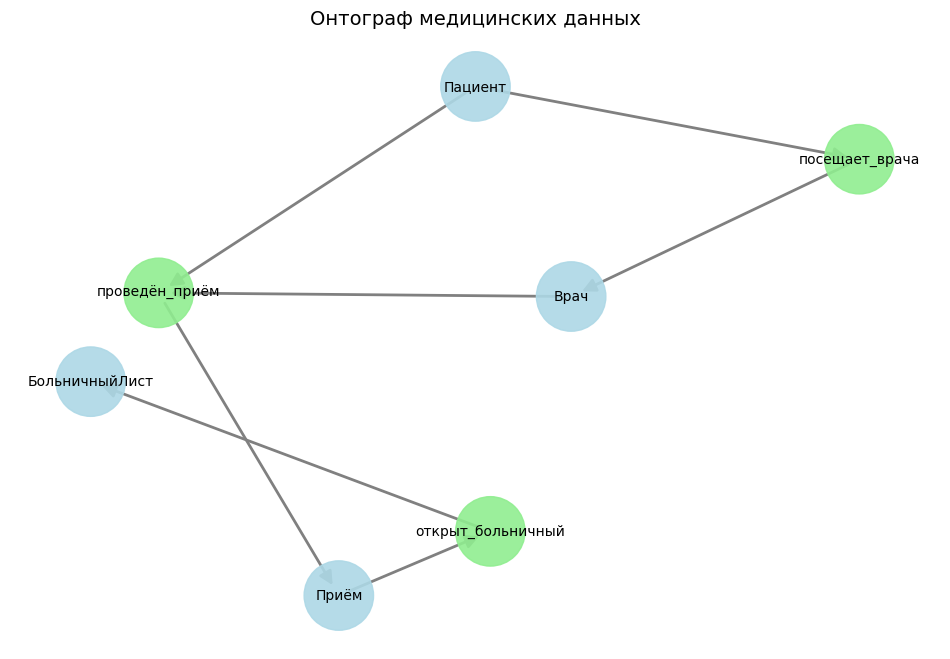

In [6]:
# Импортируем библиотеку networkx для работы с графами (создание, добавление узлов и рёбер)
import networkx as nx
# Импортируем matplotlib для визуализации графа
import matplotlib.pyplot as plt

# Создаём пустой направленный граф (DiGraph — Directed Graph)
G = nx.DiGraph()

# 1. Добавление узлов (классов и объектных свойств) 

# Перебираем все классы, определённые в онтологии onto
for cls in onto.classes():
    # Оставляем только те классы, которые принадлежат нашей онтологии 
    # и у которых имя не начинается с 'owl' 
    if cls.namespace == onto and not cls.name.startswith('owl'):
        # Добавляем узел с именем класса и атрибутом type='class' для последующей раскраски
        G.add_node(cls.name, type='class')

# Перебираем все объектные свойства (ObjectProperty) онтологии
for prop in onto.object_properties():
    # Фильтруем: только свойства из нашей онтологии, не из стандартных схем
    if prop.namespace == onto and not prop.name.startswith('owl'):
        # Добавляем узел для свойства с типом 'property'
        G.add_node(prop.name, type='property')

# 2. Добавление рёбер: domain -> property -> range 

# Для каждого объектного свойства онтологии
for prop in onto.object_properties():
    # Пропускаем свойства не из нашей онтологии
    if prop.namespace != onto:
        continue

    #  Обработка domain (откуда исходит свойство) 
    # prop.domain — список классов (или None), для которых это свойство может быть использовано
    for domain_cls in prop.domain:
        # Проверяем, что domain_cls существует, является классом и принадлежит нашей онтологии
        if domain_cls is not None and hasattr(domain_cls, 'namespace') and domain_cls.namespace == onto:
            # Добавляем ребро от класса-domain к свойству (направление: класс → свойство)
            G.add_edge(domain_cls.name, prop.name)

    # Обработка range (куда указывает свойство) 
    for range_cls in prop.range:
        if range_cls is not None and hasattr(range_cls, 'namespace') and range_cls.namespace == onto:
            # Добавляем ребро от свойства к классу-range (направление: свойство → класс)
            G.add_edge(prop.name, range_cls.name)

# 3. Диагностический вывод (для отладки) 
print("Узлы:", G.nodes)   # выводим список всех узлов графа
print("Рёбра:", G.edges)  # выводим все связи между узлами

# 4. Проверка и визуализация 
if len(G.nodes) == 0:
    # Если узлов нет — сообщаем об этом, чтобы пользователь понял, что онтология пуста
    print("Нет узлов. Онтология пуста.")
else:
    # Формируем список цветов для каждого узла в зависимости от типа
    # Если type='class' — синий, иначе (property) — зелёный
    node_colors = ['lightblue' if G.nodes[n].get('type')=='class' else 'lightgreen' for n in G.nodes]

    # Создаём фигуру для графика размером 12x8 дюймов
    plt.figure(figsize=(12,8))
    # Вычисляем позиции узлов с помощью алгоритма spring_layout (силовой макет)
    # seed=42 фиксирует случайность для воспроизводимости, k=1.5 регулирует расстояние между узлами
    pos = nx.spring_layout(G, seed=42, k=1.5)

    # Рисуем узлы: передаём позиции, цвет, размер узлов (2500) и прозрачность
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2500, alpha=0.9)
    # Рисуем рёбра: серым цветом, со стрелками, размер стрелок 20, толщина линии 2
    nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, arrowsize=20, width=2)
    # Подписываем узлы их именами, размер шрифта 10
    nx.draw_networkx_labels(G, pos, font_size=10)

    # Добавляем заголовок графика
    plt.title("Онтограф медицинских данных", fontsize=14)
    # Отключаем оси (чтобы был виден только граф)
    plt.axis('off')
    # Отображаем график
    plt.show()